# Steady-state FiCO₂–PaCO₂ conversion

## Goal

Use a simple model to estimate PaCO₂ from inspired FiCO₂, or estimate FiCO₂ from a target/achieved pressure, **conditional on physiological steady state**. Work through units, both equations, known inputs, parameter sensitivity and a literature-based comparison.

The operating slope is the participant-weighted **FiCO₂-in-medical-air** estimate. Rebreathing is a separately labelled reference. Neither slope is fitted to the validation outcomes. The exact values and results are recalculated below from the accompanying fixed literature-input export.

The model does not establish when steady state has been reached or describe onset, changing protocols, recovery or breath-by-breath responses. Model estimates are not individual measurements. This is the companion to an SSM technical note in preparation; it is not the separate dynamic-model tutorial.

<a id="reading-guide"></a>
## Reading guide

**Run all cells in order.** After execution, use these links for the core walkthrough:

1. [Quick conversion](#quick-conversion) and [your known inputs](#known-inputs)
2. [Model equations](#model-equations)
3. [One published paper, both directions](#paper-example)
4. [Sensitivity and uncertainty](#sensitivity)
5. [Agreement results](#agreement-results) and [the four-panel figure](#comparison-figure)

For the full reproduction: [assumptions](#assumptions), [slope evidence](#slope-evidence), [study selection](#study-selection), [study summaries](#study-summaries), [duration and SDs](#duration-sd), [supplementary scenarios](#supplement-scenarios), [numerical checks](#numerical-checks), and [limits / next steps](#next-steps).

Tables headed **“Expand…”** retain every row; opening them changes only the view. All calculations and checks run even when a table is closed. Scientific inputs are in `data/`, and the editable plotting code stays in the notebook.

<style>
.ssm-detail { margin: 0.7em 0; padding: 0.65em 0.8em; border: 1px solid #cbd5df; border-radius: 4px; }
.ssm-detail summary { cursor: pointer; font-weight: 600; color: #23465d; }
.ssm-detail[open] summary { margin-bottom: 0.65em; }
.jp-InputArea pre, .jp-OutputArea pre { white-space: pre-wrap; overflow-wrap: anywhere; }
@media print { .ssm-detail > * { display: block; } }
</style>


## Setup

Download or clone the complete [SSM companion repository](https://github.com/moonsukk/ssm-fico2-paco2); the notebook needs its `code/` and `data/` folders. Use Python 3.12, install `requirements.txt` in a dedicated environment, then **Restart Kernel and Run All**. Alternatively, `python run_tutorial.py` executes a fresh kernel and saves the notebook and HTML preview. No input prompts, source-PDF downloads or credentials are needed at execution time. Start with the quick conversion and editable inputs below; the detailed reproduction follows afterward.

The package contains a frozen export of selected published aggregate observations and HCVR source values, with citations and extraction locations. It reconstructs study summaries, predictions and metrics from those inputs; `data/expected_results.json` is a regression reference, not the source of predictions. The author's editable workbook is not required. This export does not perform a new literature search or change eligibility decisions.

In the repository, launch from its root with `code/` and `data/` beside the notebook. In the author workspace, launch from the project root, `tutorial/`, or `tutorial/companion/`; setup selects the complete `tutorial/companion/` package. Incomplete packages stop with a missing-file message. After switching between checkouts in a live kernel, **Restart Kernel and Run All** to avoid reusing previously imported code. PaCO₂, PETCO₂ and FiCO₂ keep a, ET and i inline; only the chemical 2 is subscripted.


In [1]:
from pathlib import Path
from dataclasses import replace
import sys, os

# Select one complete package; never combine workspace code with companion data.
cwd = Path.cwd().resolve()
candidates = [cwd, cwd/'companion', cwd/'tutorial'/'companion', cwd.parent/'companion']
module_names = ('ssm', 'tutorial_analysis', 'model_figures',
                'plot_style', 'plot_validation', 'slope_narrative')
data_names = ('settings', 'validation_inputs', 'hcvr_inputs', 'analysis_policy',
              'parameter_evidence', 'provenance', 'expected_results',
              'supplement_sensitivity_inputs')
required_files = ([f'code/{name}.py' for name in module_names]
                  + [f'data/{name}.json' for name in data_names])
missing_files = {q: [name for name in required_files if not (q/name).is_file()]
                 for q in candidates}
DATA_ROOT = next((q for q in candidates if not missing_files[q]), None)
if DATA_ROOT is None:
    closest = min(candidates, key=lambda q: len(missing_files[q]))
    raise RuntimeError(
        'Complete SSM companion not found. Open from the repository root, '
        'the author project root, or its tutorial/companion folder. '
        'Keep the supplied code/ and data/ together. '
        f'Missing from {closest}: {", ".join(missing_files[closest])}')
# A previous import from another checkout survives sys.path changes in a live kernel.
for name in module_names:
    loaded = sys.modules.get(name)
    if loaded is not None:
        origin = getattr(loaded, '__file__', None)
        if origin is None or Path(origin).resolve() != (DATA_ROOT/'code'/f'{name}.py').resolve():
            raise RuntimeError(f'{name} is already loaded from another location. '
                               'Restart Kernel and Run All to use this companion consistently.')
sys.dont_write_bytecode = True
code_path = str(DATA_ROOT/'code')
if code_path in sys.path:
    sys.path.remove(code_path)
sys.path.insert(0, code_path)
os.environ.setdefault('MPLCONFIGDIR', str(DATA_ROOT/'.cache/matplotlib'))
from ssm import Params, fico2_to_paco2, paco2_to_fico2, VERSION
print('Converter ready:', VERSION)


Converter ready: ssm-2026-09-17-medical-air


<a id="quick-conversion"></a>

## Quick start: convert in either direction

Run the setup above, then this example. It uses the default FiCO₂-in-medical-air slope, **assumes** baseline PaCO₂ = 40 mmHg and standard pressure/metabolic conditions. Enter inspired CO₂ as a **percentage**: `5.0` means 5%, not a fraction of 0.05. Pressures are in mmHg.

The first result estimates steady-state PaCO₂ for a supplied inspired percentage. The second estimates inspired percentage for a target/achieved pressure. Physiological steady state must already be established; these are model estimates, not measured individual responses. Rebreathing is reference-only later in the tutorial.


In [2]:
quick_params = Params(PaCO2_base=40.0)
quick_pressure = fico2_to_paco2(5.0, quick_params)
quick_inspired = paco2_to_fico2(50.0, quick_params)
print(f'Forward: 5.00% inspired CO₂ → estimated PaCO₂ {quick_pressure:.2f} mmHg')
print(f'Reverse: 50.00 mmHg → estimated inspired CO₂ {quick_inspired:.2f}%')
print(f'Assumed baseline: {quick_params.PaCO2_base:.1f} mmHg; operating S: {quick_params.S:.4f} L/min/mmHg')


Forward: 5.00% inspired CO₂ → estimated PaCO₂ 46.66 mmHg
Reverse: 50.00 mmHg → estimated inspired CO₂ 5.88%
Assumed baseline: 40.0 mmHg; operating S: 1.7082 L/min/mmHg


<a id="known-inputs"></a>

## Try your known inputs

Choose `conversion_direction = "forward"`, `"reverse"` or `"both"` in the next cell. Forward conversion needs **baseline + inspired percentage**. Reverse conversion needs **baseline + target/achieved pressure**. You can leave an unused input as `None`; it is not substituted or used. In `"both"` mode, each direction is checked separately, so an invalid input for one does not suppress the other result.

The prefilled 42 mmHg baseline, 5% mixture and 50 mmHg endpoint are illustrative values, not participant measurements. Replace the values you need, then rerun the input cell **and its results cell**. For optional parameters, `None` retains the displayed model assumption; a number replaces it. Required inputs are never filled from defaults. A shared baseline or parameter error prevents both estimates until corrected.

Use the same measurement compartment for baseline and achieved pressure. `PaCO2` denotes arterial inputs; choose `PETCO2` only when deliberately using end-tidal values as arterial proxies. The output pressure is still a model PaCO₂ estimate. A target is not a measured validation endpoint. Physiological steady state must already be established.

Baseline alveolar ventilation is derived from the selected baseline and CO₂ production. These editable example parameters remain separate from the fixed literature reproduction below.


In [3]:
# Choose "forward", "reverse" or "both".
conversion_direction = "both"
baseline_mmhg = 42.0                   # Required for either direction.
inspired_co2_percent = 5.0             # Forward input; None if unused.
achieved_or_target_mmhg = 50.0         # Reverse input; None if unused.
pressure_endpoint = "PaCO2"             # "PaCO2" or "PETCO2" for pressure inputs.

# OPTIONAL: None = retain the model assumption; a number = supplied input.
known_atmospheric_pressure_mmhg = None
known_co2_production_ml_min_stpd = None
known_slope_l_min_mmhg = None
known_water_vapour_pressure_mmhg = None

optional_inputs = {
    "Patm": known_atmospheric_pressure_mmhg,
    "VCO2": known_co2_production_ml_min_stpd,
    "S": known_slope_l_min_mmhg,
    "PH2O": known_water_vapour_pressure_mmhg,
}
supplied_inputs = {key: value for key, value in optional_inputs.items() if value is not None}


In [4]:
from IPython.display import display, Markdown
import math

def entered_number(value, label):
    if value is None:
        raise ValueError(f"Enter {label}; this input is required.")
    if isinstance(value, bool):
        raise ValueError(f"{label} must be a finite number, not True/False.")
    try:
        number = float(value)
    except (TypeError, ValueError, OverflowError):
        raise ValueError(f"{label} must be a finite number.") from None
    if not math.isfinite(number):
        raise ValueError(f"{label} must be a finite number.")
    return number

# Clear prior results before every run, including a run with invalid inputs.
example_params = example_forward = example_reverse = None
example_results, example_errors = {}, {}
try:
    if conversion_direction not in ("forward", "reverse", "both"):
        raise ValueError('Choose conversion_direction: "forward", "reverse" or "both".')
    if pressure_endpoint not in ("PaCO2", "PETCO2"):
        raise ValueError('Set pressure_endpoint to "PaCO2" or "PETCO2".')
    example_params = replace(
        Params(), PaCO2_base=entered_number(baseline_mmhg, "baseline pressure (mmHg)"),
        **{key: entered_number(value, key) for key, value in supplied_inputs.items()})
except ValueError as error:
    example_errors["shared"] = str(error)
    display(Markdown(f"**Shared input needs attention:** {error}"))
else:
    endpoint_label = {"PaCO2": "PaCO₂", "PETCO2": "PETCO₂"}[pressure_endpoint]
    parameter_rows = [("Baseline " + endpoint_label,
                       f"{example_params.PaCO2_base:g} mmHg", "Entered")]
    for key, label, units in [
        ("Patm", "Atmospheric pressure", "mmHg"),
        ("VCO2", "CO₂ production", "mL/min STPD"),
        ("S", "Ventilatory-response slope S", "L/min/mmHg"),
        ("PH2O", "Water-vapour pressure", "mmHg"),
    ]:
        parameter_rows.append((label, f"{getattr(example_params,key):.4g} {units}",
                               "Supplied" if key in supplied_inputs else "Default assumption"))
    parameter_rows.append(("Baseline alveolar ventilation",
                           f"{example_params.VA_base:.3f} L/min BTPS", "Derived"))
    display(Markdown("| Parameter | Value used | Source |\n|---|---|---|\n" +
                     "\n".join("| " + " | ".join(row) + " |" for row in parameter_rows)))
    if pressure_endpoint == "PETCO2":
        display(Markdown("**Proxy assumption:** end-tidal values are used as arterial "
                         "proxies; no PaCO₂–PETCO₂ offset correction is applied."))

    for direction, value, label, convert in [
        ("forward", inspired_co2_percent, "inspired CO₂ (%)", fico2_to_paco2),
        ("reverse", achieved_or_target_mmhg, "target/achieved pressure (mmHg)", paco2_to_fico2),
    ]:
        if conversion_direction not in (direction, "both"):
            continue
        try:
            value = entered_number(value, label)
            estimate = convert(value, example_params)
        except ValueError as error:
            example_errors[direction] = str(error)
            display(Markdown(f"**{direction.title()} input needs attention:** {error}"))
            continue
        example_results[direction] = estimate
        if direction == "forward":
            display(Markdown(f"**Forward:** {value:.2f}% inspired CO₂ → "
                             f"estimated PaCO₂ **{estimate:.2f} mmHg**."))
        else:
            display(Markdown(f"**Reverse:** entered {endpoint_label} {value:.2f} mmHg → "
                             f"estimated inspired CO₂ **{estimate:.2f}%**."))

example_forward = example_results.get("forward")
example_reverse = example_results.get("reverse")


| Parameter | Value used | Source |
|---|---|---|
| Baseline PaCO₂ | 42 mmHg | Entered |
| Atmospheric pressure | 760 mmHg | Default assumption |
| CO₂ production | 200 mL/min STPD | Default assumption |
| Ventilatory-response slope S | 1.708 L/min/mmHg | Default assumption |
| Water-vapour pressure | 47 mmHg | Default assumption |
| Baseline alveolar ventilation | 4.110 L/min BTPS | Derived |

**Forward:** 5.00% inspired CO₂ → estimated PaCO₂ **47.87 mmHg**.

**Reverse:** entered PaCO₂ 50.00 mmHg → estimated inspired CO₂ **5.65%**.

## Understand the model and reproduce the paper

The quick start above uses the converter alone. Continue for the equations, source-based slopes, sensitivity and literature comparison. The next cell loads the **fixed published inputs**, recomputes the results and checks them against the saved expectations. It does not use or fit to your example parameters.

Run all remaining cells in order for the complete reproduction. The parameter object `p` below belongs to that fixed analysis; `example_params` above belongs to your editable example. Changing either set of scientific inputs is not a new validation of the model.


In [5]:
from collections import defaultdict
import json, math, html
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, HTML, Markdown
from ssm import Params, fico2_to_paco2, paco2_to_fico2, VERSION
from tutorial_analysis import load_analysis, parameters
from model_figures import style, conversion_curve
from plot_validation import combined
from slope_narrative import build as build_slope_narrative
get_ipython().run_line_magic('matplotlib', 'inline')
style()
validation, plot_payload = load_analysis(DATA_ROOT)
settings = validation['settings']
slope_evidence = validation['slope_evidence']
slope_text = build_slope_narrative(validation, markdown=True)
p = parameters(settings, settings['reference_baseline_mmhg'])
assert math.isclose(p.S, slope_evidence['fico2']['slope'], abs_tol=1e-12)
print('Model:', VERSION)
print('Python:', sys.version.split()[0], '| NumPy:', np.__version__, '| Matplotlib:', matplotlib.__version__)

def show_table(rows, columns, *, detail=None):
    """All records stay in the output; optional tables can be expanded."""
    def shown(value):
        if value is None: return 'Not available'
        if isinstance(value, float): return f'{value:.4g}'
        return str(value).replace('PaCO2','PaCO₂').replace('PETCO2','PETCO₂').replace('FiCO2','FiCO₂')
    header=''.join(f'<th>{html.escape(label)}</th>' for _,label in columns)
    body=''.join('<tr>'+''.join('<td>'+html.escape(shown(row.get(field)))+'</td>'
                 for field,_ in columns)+'</tr>' for row in rows)
    table = ('<div style="overflow-x:auto"><table style="font-size:0.93em"><thead><tr>'
             +header+'</tr></thead><tbody>'+body+'</tbody></table></div>')
    if detail:
        label = html.escape(f"{detail} ({len(rows)} rows)")
        table = f'<details class="ssm-detail"><summary>{label}</summary>{table}</details>'
    display(HTML(table))

primary = next(m for m in validation['global_metrics'] if m['panel']=='C'
               and m['input_mode']=='within_paper_weighted' and m['direction']=='FiCO2_to_pressure')
display(Markdown(f"**Reproduced example result:** {primary['n_studies']} pure-HC papers; "
                 f"study-summary pressure RMSE {primary['rmse']:.2f} mmHg, bias {primary['bias']:+.2f} mmHg. "
                 "These are descriptive aggregate agreement statistics, not individual prediction accuracy."))


Model: ssm-2026-09-17-medical-air
Python: 3.12.14 | NumPy: 2.5.3 | Matplotlib: 3.10.9


**Reproduced example result:** 11 pure-HC papers; study-summary pressure RMSE 2.65 mmHg, bias -1.14 mmHg. These are descriptive aggregate agreement statistics, not individual prediction accuracy.

<a id="assumptions"></a>

## Steps

### 1. Assumptions, parameters and units

The model balances inspired and metabolically generated CO₂ under steady state:

$$P = F (P_{atm}-P_{H_2O}) + \frac{K\dot V_{CO_2}}{\dot V_{A,base}+S(P-P_{base})}, \quad \dot V_{A,base}=K\dot V_{CO_2}/P_{base}.$$

Here **F is a fraction** in the equation; the Python functions accept **percent by default**. PaCO₂ and ambient pressures are in mmHg, CO₂ production in mL min⁻¹ STPD, ventilation in L min⁻¹ BTPS and S in L min⁻¹ mmHg⁻¹. K = 0.863 mmHg L mL⁻¹ carries the gas-condition and volume scaling. Do not put an STPD mL/min value directly over a BTPS L/min value to form a dimensionless fraction without conversion.

The selected FiCO₂ slope is a measured **minute-ventilation versus end-tidal-CO₂ response**, transferred to the model's alveolar-ventilation versus arterial-CO₂ relationship as an explicit approximation. Metabolic output, barometric pressure, baseline and ventilatory response are held constant. Approximate alveolar/arterial equality does not make a PETCO₂ reading an arterial measurement. The near-linear HCVR assumption and physiologically plausible ventilation must hold at the operating point. The 80-mmHg numerical guard is not a validated physiological use range.


In [6]:
show_table([{'parameter': label, 'value': value} for label, value in [
    ('Primary FiCO₂ slope (L/min/mmHg)', p.S),
    ('Rebreathing reference slope (L/min/mmHg)', slope_evidence['rebreathing']['slope']),
    ('CO₂ production (mL/min STPD)', p.VCO2),
    ('Baseline PaCO₂ (mmHg)', p.PaCO2_base),
    ('Baseline alveolar ventilation (L/min BTPS)', p.VA_base),
    ('Atmospheric pressure (mmHg)', p.Patm),
    ('Water vapour pressure (mmHg)', p.PH2O),
    ('Numerical pressure guard (mmHg)', p.max_paco2),
]], [('parameter', 'Parameter'), ('value', 'Value')])
assert math.isclose(fico2_to_paco2(0, p), p.PaCO2_base, abs_tol=1e-10)
print(f'Linear-response ventilation at the guard: {p.VA(p.max_paco2):.2f} L/min; this is not a physiological validity claim.')


Parameter,Value
Primary FiCO₂ slope (L/min/mmHg),1.708
Rebreathing reference slope (L/min/mmHg),2.452
CO₂ production (mL/min STPD),200
Baseline PaCO₂ (mmHg),40
Baseline alveolar ventilation (L/min BTPS),4.315
Atmospheric pressure (mmHg),760
Water vapour pressure (mmHg),47
Numerical pressure guard (mmHg),80


Linear-response ventilation at the guard: 72.64 L/min; this is not a physiological validity claim.


<a id="slope-evidence"></a>

### 2. Calculate the two slopes from the literature evidence

Within each method, the participant-weighted mean is

$$S_{method}=\frac{\sum_j N_j S_j}{\sum_j N_j},\qquad
S_j=\frac{\sum_g n_{jg}S_{jg}}{\sum_g n_{jg}}.$$

Disjoint eligible subgroups contribute their participant counts; repeated tests and overlapping group/overall means do not add participants. Source selection requires healthy status and adult eligibility from source evidence or an explicit adult-eligibility assumption. Unreported minimum ages remain missing. The summed N assumes independence across papers; cross-paper participant linkage has not been established.

The source descriptions, citations, mean calculation and SD arithmetic below are generated from the same selected records as the model. The unrounded source-derived value is used throughout.

The combined participant SD is calculated from each independent source summary's sample SD, mean and participant count:

$$SD=\sqrt{\frac{\sum_i[(n_i-1)SD_i^2+n_i(S_i-S)^2]}{\sum_i n_i-1}}.$$

The FiCO₂ mean ± combined SD envelope is descriptive dispersion, not an uncertainty interval for the mean. Rebreathing is a descriptive reference, **not an operating model for transient rebreathing**, and does not enter validation residuals.


In [7]:
display(Markdown('<details class="ssm-detail"><summary>Expand source descriptions and citations</summary>\n\n' + slope_text['sources'] + '\n\n</details>'))
display(Markdown('<details class="ssm-detail"><summary>Expand slope and SD arithmetic</summary>\n\n' + slope_text['method_calculation'] + '\n\n</details>'))
method_rows = []
study_rows = []
for method in ('fico2', 'rebreathing'):
    evidence = slope_evidence[method]
    contributions = evidence['study_contributions']
    n_total = math.fsum(r['n_subjects'] for r in contributions)
    numerator = math.fsum(r['n_subjects']*r['slope'] for r in contributions)
    computed_slope = numerator/n_total
    assert math.isclose(computed_slope, evidence['slope'], abs_tol=1e-12)
    assert n_total == evidence['n_subjects']
    assert len(contributions) == evidence['n_papers']
    method_rows.append({'method': evidence['label'], 'papers': len(contributions), 'n': n_total,
                        'numerator': numerator, 'slope': computed_slope})
    study_rows.extend(dict(row, method=evidence['label']) for row in contributions)
show_table(method_rows, [('method', 'Method'), ('papers', 'Papers'), ('n', 'Contributing N'),
    ('numerator', 'ΣN × S'), ('slope', 'Weighted S (L/min/mmHg)')])
show_table(study_rows, [('study_id', 'Paper'), ('method', 'Method'), ('n_subjects', 'N'),
    ('slope', 'Study mean S (L/min/mmHg)')], detail='Expand individual slope contributions')
display(Markdown('Source papers: ' + ', '.join(f"[{r['study_id']}]({r['source_url']})" if r.get('source_url') else r['study_id']+' (source link unavailable)' for r in study_rows)))


<details class="ssm-detail"><summary>Expand source descriptions and citations</summary>

The FiCO₂ selection contains 2 papers: [Tallon (2020)](https://doi.org/10.1113/EP088293): N = 21, S = 1.77 ± 1.34 (SD); 6% CO₂ / 21% O₂ / N₂; [Peebles (2007)](https://doi.org/10.1113/jphysiol.2007.137075): N = 12, S = 1.6 ± 0.8 (SD); 4% then 8% CO₂; both 21% O₂, balance N₂; 4 min per stage. Adult eligibility is explicitly assumed for Peebles (2007); unreported minimum ages remain missing. Only the selected independent source records contribute; overlapping summaries and alternative endpoints from the same cohort are not added again. The reported participant-slope means are used; ratios of group mean changes are different calculations. Finite exposure alone does not establish the ventilatory steady state required by the model.

</details>

<details class="ssm-detail"><summary>Expand slope and SD arithmetic</summary>

For each protocol, the participant-count-weighted slope is calculated as S = Σ(NᵢSᵢ)/ΣNᵢ, after combining compatible independent subgroups within a paper and counting repeated cohorts once. The FiCO₂ estimate is (21 × 1.77 + 12 × 1.6) / 33 = 1.70818182 L min⁻¹ mmHg⁻¹ (ΣNᵢSᵢ = 56.37; 2 papers). Conversions and validation use the full-precision source-derived value rather than the displayed rounding. The combined participant SD is 1.16153, calculated from within-source and between-source sums of squares (42.952 + 0.220690909) divided by 32 degrees of freedom, then taking the square root. It describes participant dispersion, not uncertainty in the mean. The rebreathing estimate is 679.09 / 277 = 2.45158845 L min⁻¹ mmHg⁻¹, from 9 papers. Rebreathing is reference only. The operating-slope sources do not enter the current exact validation set. Participant independence across papers is assumed, and the model default is not an individual ventilatory-response estimate.

</details>

Method,Papers,Contributing N,ΣN × S,Weighted S (L/min/mmHg)
FiCO₂ in medical air,2,33,56.37,1.708
Rebreathing,9,277,679.1,2.452


Paper,Method,N,Study mean S (L/min/mmHg)
Tallon2020,FiCO₂ in medical air,21,1.77
Peebles2007,FiCO₂ in medical air,12,1.6
Hirshman1975,Rebreathing,43,2.69
Patrick1972,Rebreathing,37,1.973
Aitken1986,Rebreathing,47,4.057
Miyamura1976,Rebreathing,6,3.757
Kronenberg1973,Rebreathing,16,2.7
Brischetto1984,Rebreathing,20,2.04
Miyamura1985,Rebreathing,77,1.622
Mahler1982,Rebreathing,20,2.23


Source papers: [Tallon2020](https://doi.org/10.1113/EP088293), [Peebles2007](https://doi.org/10.1113/jphysiol.2007.137075), [Hirshman1975](https://doi.org/10.1152/jappl.1975.38.6.1095), [Patrick1972](https://doi.org/10.1016/0034-5687(72)90063-1), [Aitken1986](https://doi.org/10.1152/jappl.1986.60.6.1894), [Miyamura1976](https://doi.org/10.1007/BF01062905), [Kronenberg1973](https://doi.org/10.1172/JCI107363), [Brischetto1984](https://doi.org/10.1152/jappl.1984.56.5.1143), [Miyamura1985](https://doi.org/10.2170/jjphysiol.35.169), [Mahler1982](https://doi.org/10.1152/jappl.1982.52.2.388), [Nickol2009](https://doi.org/10.1016/j.rmed.2008.08.013)

**View the two source slopes in the model.**


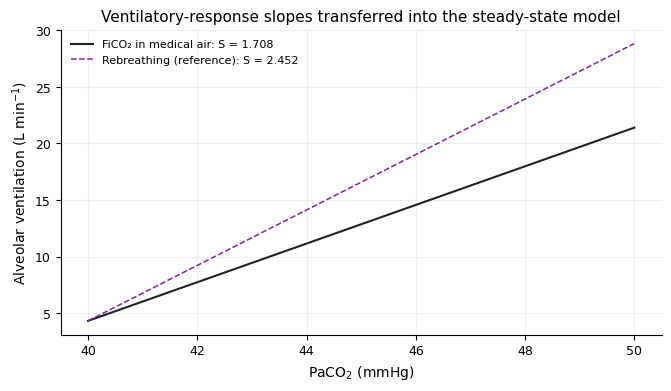

**Read the plot:** the operating slope is 1.708 L/min/mmHg; the rebreathing reference is 2.452. These lines transfer the source slopes into alveolar ventilation; they do not demonstrate that the two ventilation measurements are equivalent.

In [8]:
pressure_grid = np.linspace(p.PaCO2_base, p.PaCO2_base+10, 101)
fig, ax = plt.subplots(figsize=(6.6, 3.8), layout='constrained')
for method, color, line, width in [('fico2', '#202326', '-', 1.5), ('rebreathing', '#7B2D8D', '--', 1.1)]:
    item = slope_evidence[method]
    scenario = replace(p, S=item['slope'])
    ax.plot(pressure_grid, [scenario.VA(x) for x in pressure_grid], line, color=color, lw=width,
            label=f"{item['label']}{' (reference)' if method=='rebreathing' else ''}: S = {scenario.S:.3f}")
ax.set(xlabel=r'PaCO$_2$ (mmHg)', ylabel=r'Alveolar ventilation (L min$^{-1}$)',
       title='Ventilatory-response slopes transferred into the steady-state model')
ax.legend(frameon=False, fontsize=8); ax.grid(alpha=.18)
plt.show()
display(Markdown(
    f"**Read the plot:** the operating slope is {p.S:.3f} L/min/mmHg; "
    f"the rebreathing reference is {slope_evidence['rebreathing']['slope']:.3f}. "
    "These lines transfer the source slopes into alveolar ventilation; "
    "they do not demonstrate that the two ventilation measurements are equivalent."))


<a id="model-equations"></a>

### 3. Equations and further conversion examples

Use the **FiCO₂-in-medical-air slope** for the model. At sea-level conditions and baseline 40 mmHg, the example below converts a 5% inspired mixture to an equilibrium PaCO₂ estimate, then converts a target 50 mmHg back to an inspired percentage. All example numbers are calculated from the packaged settings.

These are model-based equilibrium estimates; selecting a gas challenge for an individual requires more information than a population conversion.

### The equations used by the functions

Write $G=K\dot V_{CO_2}$, $P_i=F(P_{atm}-P_{H_2O})$ and $D=G/P_{base}-SP_{base}$. Here $F$ is a fraction.

For a supplied pressure:

$$F=\frac{P-G/[G/P_{base}+S(P-P_{base})]}{P_{atm}-P_{H_2O}}.$$

For supplied inspired CO₂ and $S>0$, the physical upper root is:

$$P=\frac{SP_i-D+\sqrt{(D-SP_i)^2+4S(P_iD+G)}}{2S}.$$

The code evaluates the equivalent root in a numerically stable form. At $S=0$, $P=P_{base}+P_i$. Multiply $F$ by 100 to report percent. The functions reject results outside the supported numerical branch.

The literature evaluation covers **2–7% inspired CO₂**. An 8% worked example or a wider curve is a model illustration, not validation at that dose; neither is the 80-mmHg software guard an accuracy or safety boundary.


In [9]:
estimated_paco2 = fico2_to_paco2(5.0, p)
estimated_fico2 = paco2_to_fico2(50.0, p)
print(f'Primary FiCO₂ slope = {p.S:.4f} L/min/mmHg')
print(f"5% inspired CO₂ → {estimated_paco2:.4f} mmHg ({estimated_paco2*settings['kpa_per_mmhg']:.4f} kPa)")
print(f'50 mmHg → {estimated_fico2:.4f}% inspired CO₂')
print(f'Round trip: {paco2_to_fico2(estimated_paco2,p):.10f}%')
assert math.isclose(fico2_to_paco2(0.05,p,is_percent=False), estimated_paco2, abs_tol=1e-10)
examples = [{'fico2_pct': f, 'inspired_pressure': f*p.Pdry/100,
             'estimate_mmhg': fico2_to_paco2(f,p),
             'estimate_kpa': fico2_to_paco2(f,p)*settings['kpa_per_mmhg']} for f in (0,2,5,7,8)]
show_table(examples, [('fico2_pct', 'FiCO₂ (%)'), ('inspired_pressure', 'PiCO₂ (mmHg)'),
                     ('estimate_mmhg', 'PaCO₂ estimate (mmHg)'), ('estimate_kpa', 'PaCO₂ estimate (kPa)')])


Primary FiCO₂ slope = 1.7082 L/min/mmHg
5% inspired CO₂ → 46.6553 mmHg (6.2202 kPa)
50 mmHg → 5.8813% inspired CO₂
Round trip: 5.0000000000%


FiCO₂ (%),PiCO₂ (mmHg),PaCO₂ estimate (mmHg),PaCO₂ estimate (kPa)
0,0,40,5.333
2,14.26,41.22,5.496
5,35.65,46.66,6.22
7,49.91,55.51,7.401
8,57.04,61.28,8.17


<a id="sensitivity"></a>

### 4. Sensitivity and uncertainty

The local derivatives follow from implicit differentiation. Writing $G=K\dot V_{CO_2}$ and $V=\dot V_A(P)$, and holding baseline fixed:

$$\frac{dP}{dF_{\%}}=\frac{(P_{atm}-P_{H_2O})/100}{1+GS/V^2},\qquad \frac{dP}{dS}=-\frac{G(P-P_{base})/V^2}{1+GS/V^2}.$$

These derivatives quantify local sensitivity, not empirically established uncertainty. A confidence or prediction interval would require justified parameter/error distributions and dependence assumptions, which are not available in this release.

The following shared-axis graph uses each method's explicitly labelled evidence range, described from the current source selection below. Neither shaded envelope is a confidence interval or prediction interval. Baseline, gas delivery, metabolic output, measurement-compartment differences and the minute/alveolar-ventilation transfer remain outside these envelopes.


The FiCO₂-in-medical-air sensitivity bounds are 0.55–2.87 L min⁻¹ mmHg⁻¹, representing the participant-weighted mean ± combined participant SD from 2 papers. The rebreathing bounds span eligible study-level means from 9 papers, 1.62–4.06. These are different descriptive sensitivity scenarios, not confidence or individual prediction intervals. Published minute-ventilation slopes are used as first-order alveolar-ventilation proxies.

At 5%: dP/dFiCO₂_percent = 3.2429 mmHg per percentage point
At 5%: dP/dS = -2.1241 mmHg per (L/min/mmHg)


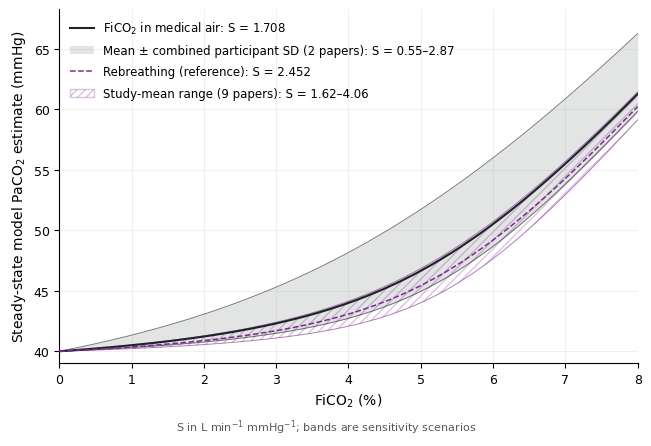

FiCO₂ in medical air : FiCO₂ participant-weighted mean ± combined participant SD; descriptive dispersion, not SE or a confidence interval = [0.5466541211770972, 2.869709515186539]
Rebreathing : Range of eligible rebreathing study means; not individual extrema or a confidence interval = [1.6223376623376624, 4.057446808510638]


**Read the envelopes:** changing the transferred slope changes the equilibrium estimate. FiCO₂ dispersion and the rebreathing study-mean range have different meanings; neither is a prediction interval.

In [10]:
display(Markdown(slope_text['sensitivity']))
P = fico2_to_paco2(5,p); V = p.VA(P); G = p.K*p.VCO2
print(f'At 5%: dP/dFiCO₂_percent = {(p.Pdry/100)/(1+G*p.S/V**2):.4f} mmHg per percentage point')
print(f'At 5%: dP/dS = {-(G*(P-p.PaCO2_base)/V**2)/(1+G*p.S/V**2):.4f} mmHg per (L/min/mmHg)')
from model_figures import sensitivity_figure
figure = sensitivity_figure(p,slope_evidence)
display(figure)
plt.close(figure)
for method in ('fico2','rebreathing'):
    item=slope_evidence[method]
    print(item['label'], ':', item['range_label'], '=', item['range'])

display(Markdown('**Read the envelopes:** changing the transferred slope changes '
    'the equilibrium estimate. FiCO₂ dispersion and the rebreathing study-mean range '
    'have different meanings; neither is a prediction interval.'))


<a id="study-selection"></a>

### 5. Load the source-defined validation comparisons

Panels A–C require healthy adults, pure inspired-CO₂ exposure, a reported supplied percentage, and absolute baseline and achieved measured PaCO₂ or PETCO₂. Panel D repeats pure HC and adds all eligible exact mixed-HC arms. Hyperoxic, hypoxic and other coexposure contexts remain identified. Graphical readings, nominal/target-equivalent doses and unknown delivered mixtures do not enter the exact primary comparison.

Xu2011 and Kety1948 retain explicit healthy-adult eligibility assumptions where source age bounds were not established; source-supported eligibility is identified separately. No duration-only exclusion or universal steady-state threshold is applied.

FiCO₂ is the paper's reported supplied mixture, not an independently measured effective airway dose for every participant. Delivery and protocol qualifications remain in the source tables. The model uses each record's matching baseline and the selected FiCO₂ slope; it never uses the achieved endpoint to obtain its own forward-validation prediction.


In [11]:
primary_reported = validation['primary_reported']
primary_weighted = validation['primary_weighted']
weighted_points = validation['weighted_points']
mixed_weighted = validation['mixed_weighted']
print('Primary reported observations:', len(primary_reported), '| papers:', len({r['study_id'] for r in primary_reported}))
print('Primary study summaries:', len(primary_weighted))
print('Panel D: reported observations',len(validation['reported_points']), '| study summaries',len(weighted_points))
print('Pure-HC inspired concentrations (%):',sorted({r['fico2_pct'] for r in primary_reported}))
print('Adult assumptions:', ', '.join(validation['agreement_policy']['assumed_adult_studies']))
print('Primary operating slope:', settings['S'], 'L/min/mmHg')
assert all(r['context']=='pure_HC' for r in primary_reported+primary_weighted)
assert all(r['population'] in ('healthy_adults','healthy_adults_assumed') for r in validation['reported_points'])
show_table(plot_payload['comparison_membership'], [('study_id','Paper'),('context','Gas condition'),
    ('fico2_pct','FiCO₂ (%)'),('reported_points','Reported observations'),
    ('subject_weighted_points','Study summaries'),('condition_in_ABC','In A–C')], detail='Expand all paper / condition memberships')


source_papers = {}
for row in validation['reported_points']:
    source_papers.setdefault(row['study_id'], row)
display(Markdown('**Validation source papers:**\n\n'+'\n'.join(
    f"- [{name}]({row['source_url']}): {row.get('source_title','')}"
    for name,row in sorted(source_papers.items()))))


Primary reported observations: 27 | papers: 11
Primary study summaries: 20
Panel D: reported observations 40 | study summaries 27
Pure-HC inspired concentrations (%): [2.0, 3.0, 4.0, 5.0, 6.0, 7.0]
Adult assumptions: Kety1948, Xu2011
Primary operating slope: 1.7081818181818182 L/min/mmHg


Paper,Gas condition,FiCO₂ (%),Reported observations,Study summaries,In A–C
Ashkanian2008,HC_hyperoxia,5,1,1,False
Ashkanian2008,pure_HC,5,1,1,True
Chawla2015,pure_HC,5,3,1,True
Deckers2022,HC_hyperoxia,5,1,1,False
Deckers2022,pure_HC,5,1,1,True
Jain2011,pure_HC,5,1,1,True
Kety1948,HC_N2O_15pct,5,6,1,False
Kety1948,HC_N2O_15pct,7,2,1,False
Miller2019,pure_HC,4,2,1,True
Miller2019,pure_HC,6,2,1,True


**Validation source papers:**

- [Ashkanian2008](https://doi.org/10.1016/j.neuroscience.2008.08.016): Improvement of brain tissue oxygenation by inhalation of carbogen
- [Chawla2015](https://doi.org/10.3174/ajnr.A4424): Whole-Brain N -Acetylaspartate Concentration Is Preserved during Mild Hypercapnia Challenge
- [Deckers2022](https://doi.org/10.1177/0271678X211064572): Hemodynamic and metabolic changes during hypercapnia with normoxia and hyperoxia using pCASL and TRUST MRI in healthy adults
- [Jain2011](https://doi.org/10.1038/jcbfm.2011.34): Rapid magnetic resonance measurement of global cerebral metabolic rate of oxygen consumption in humans during rest and hypercapnia
- [Kety1948](https://doi.org/10.1172/JCI101995): The effects of altered arterial tensions of carbon dioxide and oxygen on cerebral blood flow and cerebral oxygen consumption of normal young men
- [Miller2019](https://doi.org/10.3389/fnagi.2019.00281): Age-Related Reductions in Cerebrovascular Reactivity Using 4D Flow MRI
- [Reynolds1972](https://doi.org/10.1152/jappl.1972.33.1.47): Transient ventilatory response to graded hypercapnia in man.
- [Rodgers2015](https://doi.org/10.1016/j.neuroimage.2014.10.061): Rapid T2- and susceptometry-based CMRO2 quantification with interleaved TRUST (iTRUST)
- [Rostrup2000](https://doi.org/10.1006/nimg.1999.0526): Regional Differences in the CBF and BOLD Responses to Hypercapnia: A Combined PET and fMRI Study
- [Xie2006](https://doi.org/10.1113/jphysiol.2006.110627): Influence of cerebrovascular function on the hypercapnic ventilatory response in healthy humans
- [Xu2011](https://doi.org/10.1038/jcbfm.2010.153): The Influence of Carbon Dioxide on Brain Activity and Metabolism in Conscious Humans
- [Yezhuvath2009](https://doi.org/10.1002/nbm.1392): On the assessment of cerebrovascular reactivity using hypercapnia BOLD MRI

<a id="paper-example"></a>

### 5a. Follow one paper through both conversions

[Jain et al. (2011)](https://doi.org/10.1038/jcbfm.2011.34) studied ten healthy adult men during a reported 5% CO₂ mixture (20% O₂, balance N₂). We use the end-tidal group means in **Table 1, printed p. 1507**; the participant and gas-protocol details are on **p. 1505**. The paper calls this endpoint EtCO₂; we label it PETCO₂ consistently here.

The next cell reads the paper's existing record from `data/validation_inputs.json`. It does not copy a saved model prediction. Baseline and achieved values are **measured group means**; FiCO₂ is the **reported supplied mixture**. Other model parameters retain the fixed analysis assumptions, including the FiCO₂-in-medical-air slope derived from separate HCVR papers.


In [12]:
source_records = json.loads((DATA_ROOT/'data/validation_inputs.json').read_text())['records']
jain_matches = [row for row in source_records if row['record_id'] == 'Jain2011_5pct']
assert len(jain_matches) == 1
jain_source = jain_matches[0]
assert jain_source['source_pressure_unit'] == 'mmHg'
assert jain_source['endpoint'] == jain_source['baseline_endpoint'] == 'PETCO2'
assert jain_source['context'] == 'pure_HC' and jain_source['population'] == 'healthy_adults'

jain_baseline = float(jain_source['baseline_source_value'])
jain_achieved = float(jain_source['endpoint_source_value'])
jain_dose = float(jain_source['fico2_pct'])
show_table([
    {'quantity': 'Baseline PETCO₂', 'value': jain_baseline, 'unit': 'mmHg',
     'forward': 'Input', 'reverse': 'Input'},
    {'quantity': 'Achieved PETCO₂', 'value': jain_achieved, 'unit': 'mmHg',
     'forward': 'Measured comparator', 'reverse': 'Input'},
    {'quantity': 'Reported FiCO₂', 'value': jain_dose, 'unit': '%',
     'forward': 'Input', 'reverse': 'Reported comparator'},
], [('quantity', 'Paper value'), ('value', 'Mean / dose'), ('unit', 'Unit'),
    ('forward', 'Forward use'), ('reverse', 'Reverse use')])
print(f"Source record: {jain_source['record_id']} | N = {jain_source['subjects_n']}")
print(f"Reported SDs: baseline {jain_source['baseline_uncertainty_value']:g} mmHg; "
      f"achieved {jain_source['endpoint_uncertainty_value']:g} mmHg.")


Paper value,Mean / dose,Unit,Forward use,Reverse use
Baseline PETCO₂,39,mmHg,Input,Input
Achieved PETCO₂,47,mmHg,Measured comparator,Input
Reported FiCO₂,5,%,Input,Reported comparator


Source record: Jain2011_5pct | N = 10
Reported SDs: baseline 1 mmHg; achieved 2 mmHg.


**Calculate, then compare.** Forward conversion uses baseline and FiCO₂, leaving the achieved measurement out of the prediction. Reverse conversion uses baseline and achieved pressure, leaving the reported FiCO₂ out of the estimate. Both directions use the same fixed model and the same paper.

Define the pressure error as **model PaCO₂ − measured PETCO₂**, in mmHg, and the inspired-concentration error as **estimated FiCO₂ − reported FiCO₂**, in percentage points. This comparison assumes PETCO₂ can initialize and be compared with the arterial model by proxy; it does not turn the end-tidal readings into arterial measurements.


In [13]:
jain_params = parameters(settings, jain_baseline)
jain_pressure_estimate = fico2_to_paco2(jain_dose, jain_params)
jain_dose_estimate = paco2_to_fico2(jain_achieved, jain_params)
jain_pressure_error = jain_pressure_estimate - jain_achieved
jain_dose_error = jain_dose_estimate - jain_dose

show_table([
    {'direction': 'Forward: PaCO₂ model vs measured PETCO₂',
     'estimate': f'{jain_pressure_estimate:.2f}', 'reported': f'{jain_achieved:.2f}',
     'error': f'{jain_pressure_error:+.2f}', 'unit': 'mmHg'},
    {'direction': 'Reverse: inspired CO₂',
     'estimate': f'{jain_dose_estimate:.2f}%', 'reported': f'{jain_dose:.2f}%',
     'error': f'{jain_dose_error:+.2f}', 'unit': 'percentage points'},
], [('direction', 'Comparison'), ('estimate', 'Model estimate'),
    ('reported', 'Paper comparator'), ('error', 'Estimate − comparator'), ('unit', 'Error unit')])
print(f'Fixed S = {jain_params.S:.8f} L/min/mmHg; baseline = {jain_params.PaCO2_base:g} mmHg')
print(f'Pressure error: {jain_pressure_estimate:.2f} − {jain_achieved:.2f} = {jain_pressure_error:+.2f} mmHg')
print(f'FiCO₂ error: {jain_dose_estimate:.2f}% − {jain_dose:.2f}% = {jain_dose_error:+.2f} percentage points')


Comparison,Model estimate,Paper comparator,Estimate − comparator,Error unit
Forward: PaCO₂ model vs measured PETCO₂,46.09,47.00,-0.91,mmHg
Reverse: inspired CO₂,5.25%,5.00%,+0.25,percentage points


Fixed S = 1.70818182 L/min/mmHg; baseline = 39 mmHg
Pressure error: 46.09 − 47.00 = -0.91 mmHg
FiCO₂ error: 5.25% − 5.00% = +0.25 percentage points


In [14]:
jain_reported = next(row for row in primary_reported if row['record_id'] == jain_source['record_id'])
jain_summary = next(row for row in primary_weighted if row['study_id'] == 'Jain2011')
for row in (jain_reported, jain_summary):
    assert math.isclose(jain_baseline, row['baseline_mmhg'], abs_tol=1e-12)
    assert math.isclose(jain_achieved, row['measured_mmhg'], abs_tol=1e-12)
    assert math.isclose(jain_pressure_estimate, row['estimated_paco2_mmhg'], abs_tol=1e-10)
    assert math.isclose(jain_dose_estimate, row['estimated_fico2_pct'], abs_tol=1e-10)
assert jain_summary['subjects_n'] == jain_source['subjects_n']
assert jain_params.S == p.S == settings['S']
pressure_relation = 'below' if jain_pressure_error < 0 else 'above' if jain_pressure_error > 0 else 'equal to'
dose_relation = 'below' if jain_dose_error < 0 else 'above' if jain_dose_error > 0 else 'equal to'
display(Markdown(
    f"**Read the signs:** the forward estimate is {abs(jain_pressure_error):.2f} mmHg {pressure_relation} "
    f"the reported end-tidal mean. The reverse estimate is {abs(jain_dose_error):.2f} percentage points "
    f"{dose_relation} the reported inspired concentration. These are two residuals from one aggregate "
    "comparison, not independent validation datasets, individual prediction errors or the full-analysis RMSE/bias.\n\n"
    "**Reported versus study summary:** this paper supplies one cohort mean pair. Both representations "
    "therefore use the same baseline and achieved means and give the same estimates; multiplying both "
    "means by the same N does not create a different subject-weighted mean. Do not count the cohort twice.\n\n"
    "**Source limits:** the reported 3-minute exposure is not proof of arterial steady state. Table 1 does "
    "not specify the exact PETCO₂ averaging window. Its ±1 and ±2 mmHg values are between-subject SDs, "
    "not confidence intervals, model-error SDs or a validated tolerance. "
    "The calculation reproduces the existing literature comparison; no source value or model parameter is fitted."))


**Read the signs:** the forward estimate is 0.91 mmHg below the reported end-tidal mean. The reverse estimate is 0.25 percentage points above the reported inspired concentration. These are two residuals from one aggregate comparison, not independent validation datasets, individual prediction errors or the full-analysis RMSE/bias.

**Reported versus study summary:** this paper supplies one cohort mean pair. Both representations therefore use the same baseline and achieved means and give the same estimates; multiplying both means by the same N does not create a different subject-weighted mean. Do not count the cohort twice.

**Source limits:** the reported 3-minute exposure is not proof of arterial steady state. Table 1 does not specify the exact PETCO₂ averaging window. Its ±1 and ±2 mmHg values are between-subject SDs, not confidence intervals, model-error SDs or a validated tolerance. The calculation reproduces the existing literature comparison; no source value or model parameter is fitted.

<a id="study-summaries"></a>

### 6. Study summaries: average compatible inputs within a paper before converting

For one paper, context, endpoint and inspired dose, average repeated measurements within each participant or shared cohort first. Then form baseline and achieved means across independent compatible participant groups, using each group's participant count once:

$$\overline{P}_{base}=\frac{\sum_g n_g\overline{P}_{base,g}}{\sum_g n_g},\qquad
\overline{P}_{achieved}=\frac{\sum_g n_g\overline{P}_{achieved,g}}{\sum_g n_g}.$$

Apply the steady-state model **after** these means are formed. Do not average predictions and label that result a conversion of the weighted mean: the relationship is nonlinear. Keep separate endpoints, contexts and inspired doses separate even when participants overlap.

A single reported cohort mean already supplies its available study summary. Without participant data, a second subject mean cannot be reconstructed. Chawla's three acquisition means share twelve participants, and Rodgers' two CMRO₂ methods share one capnography measurement. Repeated acquisitions do not add participants.

**Study summary** is the primary representation; **Reported observations** is a sensitivity representation of the same evidence. Legacy file/field names containing `weighted` remain compatibility identifiers. These within-paper calculations are distinct from participant weighting of literature HCVR slopes across papers.


In [15]:
show_table(primary_weighted, [('study_id','Paper'),('endpoint','Endpoint'),('subjects_n','N'),
    ('fico2_pct','FiCO₂ (%)'),('baseline_mmhg','Summary baseline (mmHg)'),('measured_mmhg','Summary achieved (mmHg)')], detail='Expand every pure-HC study summary')
chawla_reported = [r for r in primary_reported if r['study_id']=='Chawla2015']
chawla = next(r for r in primary_weighted if r['study_id']=='Chawla2015')
mean_baseline = math.fsum(r['baseline_mmhg'] for r in chawla_reported)/len(chawla_reported)
mean_achieved = math.fsum(r['measured_mmhg'] for r in chawla_reported)/len(chawla_reported)
chawla_params = parameters(settings,mean_baseline)
after_mean = fico2_to_paco2(chawla['fico2_pct'],chawla_params)
mean_predictions = math.fsum(r['estimated_paco2_mmhg'] for r in chawla_reported)/len(chawla_reported)
print(f"Chawla: {len(chawla_reported)} acquisitions share N={chawla['subjects_n']}.")
print(f'Convert the mean baseline: {after_mean:.6f} mmHg; average acquisition predictions: {mean_predictions:.6f} mmHg.')
assert math.isclose(mean_baseline,chawla['baseline_mmhg'],abs_tol=1e-12)
assert math.isclose(mean_achieved,chawla['measured_mmhg'],abs_tol=1e-12)
assert math.isclose(after_mean,chawla['estimated_paco2_mmhg'],abs_tol=1e-12)


Paper,Endpoint,N,FiCO₂ (%),Summary baseline (mmHg),Summary achieved (mmHg)
Ashkanian2008,PaCO₂,10,5,40.8,46.05
Chawla2015,PETCO₂,12,5,42.77,51.6
Deckers2022,PETCO₂,10,5,45,49.2
Jain2011,PETCO₂,10,5,39,47
Miller2019,PETCO₂,39,4,40,46.51
Miller2019,PETCO₂,39,6,40,48.51
Reynolds1972,PETCO₂,10,3,42.2,44.3
Reynolds1972,PETCO₂,10,5,43.6,47.5
Reynolds1972,PETCO₂,10,6,42.5,48.9
Reynolds1972,PETCO₂,14,7,43.1,56.2


Chawla: 3 acquisitions share N=12.
Convert the mean baseline: 48.356246 mmHg; average acquisition predictions: 48.387002 mmHg.


### 7. Forward check: inspired percentage → achieved pressure

For each paper use its baseline and reported FiCO₂ as inputs, then compare the model-estimated PaCO₂ with that paper's achieved measured endpoint:

$$\widehat P=f(F;\overline P_{base},S_{FiCO_2}),\qquad e_P=\widehat P-\overline P_{achieved}\quad\text{(mmHg)}.$$

The achieved endpoint is held out of the forward calculation. With PETCO₂, the baseline initializes the arterial model by proxy and the achieved end-tidal value is the comparison endpoint. This is not direct arterial validation.


In [16]:
show_table(primary_weighted,[('study_id','Paper'),('endpoint','Measured endpoint'),
    ('fico2_pct','Input FiCO₂ (%)'),('baseline_mmhg','Input baseline (mmHg)'),
    ('measured_mmhg','Achieved (mmHg)'),('estimated_paco2_mmhg','Model PaCO₂ (mmHg)'),
    ('pressure_error_mmhg','Model − achieved (mmHg)')], detail='Expand every forward comparison')


Paper,Measured endpoint,Input FiCO₂ (%),Input baseline (mmHg),Achieved (mmHg),Model PaCO₂ (mmHg),Model − achieved (mmHg)
Ashkanian2008,PaCO₂,5,40.8,46.05,47.13,1.075
Chawla2015,PETCO₂,5,42.77,51.6,48.36,-3.244
Deckers2022,PETCO₂,5,45,49.2,49.86,0.6635
Jain2011,PETCO₂,5,39,47,46.09,-0.9112
Miller2019,PETCO₂,4,40,46.51,44,-2.512
Miller2019,PETCO₂,6,40,48.51,50.52,2.01
Reynolds1972,PETCO₂,3,42.2,44.3,44.23,-0.07036
Reynolds1972,PETCO₂,5,43.6,47.5,48.91,1.405
Reynolds1972,PETCO₂,6,42.5,48.9,51.59,2.691
Reynolds1972,PETCO₂,7,43.1,56.2,56.38,0.1779


### 8. Reverse check: achieved pressure → inspired percentage

For the same paper use its baseline and achieved measured endpoint as inputs, then compare the estimated FiCO₂ with the paper's reported inspired percentage:

$$\widehat F=f^{-1}(\overline P_{achieved};\overline P_{base},S_{FiCO_2}),\qquad e_F=\widehat F-F\quad\text{(percentage points)}.$$

The reported inspired percentage is held out of the reverse calculation. An error of +1 percentage point means an estimate of 6% for a reported 5% mixture; it is not a 1% relative error. Using achieved PETCO₂ as an arterial proxy remains a model assumption.

The directions use the same relationship and evidence. They assess agreement in different output units; they are not independent validation datasets.


In [17]:
show_table(primary_weighted,[('study_id','Paper'),('endpoint','Input endpoint'),
    ('baseline_mmhg','Input baseline (mmHg)'),('measured_mmhg','Input achieved (mmHg)'),
    ('fico2_pct','Reported FiCO₂ (%)'),('estimated_fico2_pct','Model FiCO₂ (%)'),
    ('fico2_error_pct_points','Model − reported (percentage points)')], detail='Expand every reverse comparison')


Paper,Input endpoint,Input baseline (mmHg),Input achieved (mmHg),Reported FiCO₂ (%),Model FiCO₂ (%),Model − reported (percentage points)
Ashkanian2008,PaCO₂,40.8,46.05,5,4.625,-0.3749
Chawla2015,PETCO₂,42.77,51.6,5,5.971,0.9713
Deckers2022,PETCO₂,45,49.2,5,4.702,-0.2983
Jain2011,PETCO₂,39,47,5,5.254,0.2538
Miller2019,PETCO₂,40,46.51,4,4.956,0.9557
Miller2019,PETCO₂,40,48.51,6,5.52,-0.4797
Reynolds1972,PETCO₂,42.2,44.3,3,3.06,0.06002
Reynolds1972,PETCO₂,43.6,47.5,5,4.383,-0.6173
Reynolds1972,PETCO₂,42.5,48.9,6,5.244,-0.7562
Reynolds1972,PETCO₂,43.1,56.2,7,6.965,-0.0354


<a id="agreement-results"></a>

### 9. Give each paper equal total influence

The two representations are summarized separately. Within a given panel or dose/context and representation, let $J$ be the number of papers and $m_j$ the retained comparisons from paper $j$:

$$\operatorname{bias}=\frac{1}{J}\sum_j\frac{1}{m_j}\sum_i e_{ji},\qquad
\operatorname{RMSE}=\sqrt{\frac{1}{J}\sum_j\frac{1}{m_j}\sum_i e_{ji}^{2}}.$$

Thus a paper with repeated acquisitions does not gain additional total influence. Endpoint-specific results additionally stratify by endpoint. Global metrics pool the complete C (pure HC) or D (pure-plus-mixed HC) dataset, sharing each paper’s total weight equally across its retained doses, endpoints and contexts. They are descriptive summaries of that mixture, not causal pure-versus-mixed comparisons. Dose/context metrics remain available; raw inputs are never averaged across doses or contexts. Every residual uses the FiCO₂ slope and its matching baseline, not the baseline-40 illustrative reference curve.

Combining PaCO₂/PETCO₂ comparisons is a mixed-compartment literature agreement analysis; it does not make the measurements interchangeable or establish individual accuracy or precision. Measured SD bars do not determine metric weights. Reported observations and study summaries reuse the same evidence.


In [18]:
display(Markdown('**Global panel agreement (both directions)**'))
show_table(validation['global_metrics'], [('panel','Panel'),('direction','Direction'),('representation_label','Representation'),('n_studies','Papers'),('n_points','Comparisons'),('units','Units'),('bias','Bias'),('rmse','RMSE')])

primary_reverse = next(m for m in validation['global_metrics']
    if m['panel'] == 'C' and m['input_mode'] == 'within_paper_weighted'
    and m['direction'] == 'pressure_to_FiCO2')
display(Markdown(
    f"**Read the primary results:** {primary['n_studies']} pure-HC papers; "
    f"study-summary pressure RMSE **{primary['rmse']:.2f} mmHg**, "
    f"bias **{primary['bias']:+.2f} mmHg**. In reverse, FiCO₂ RMSE is "
    f"**{primary_reverse['rmse']:.2f} percentage points**, "
    f"bias **{primary_reverse['bias']:+.2f} percentage points**. "
    "Both directions use the same evidence and equal paper influence. "
    "They describe aggregate agreement, not individual prediction accuracy."))
display(Markdown('Endpoint-specific results remain in `validation["metrics"]`; '
    'their different source/dose mixtures do not establish an intrinsic endpoint accuracy ranking.'))


**Global panel agreement (both directions)**

Panel,Direction,Representation,Papers,Comparisons,Units,Bias,RMSE
C,FiCO₂_to_pressure,Reported observations,11,27,mmHg,-1.174,2.646
C,pressure_to_FiCO₂,Reported observations,11,27,percentage points FiCO₂,0.3408,0.7332
C,FiCO₂_to_pressure,Study summary,11,20,mmHg,-1.136,2.65
C,pressure_to_FiCO₂,Study summary,11,20,percentage points FiCO₂,0.3324,0.7286
D,FiCO₂_to_pressure,Reported observations,12,40,mmHg,-1.137,2.706
D,pressure_to_FiCO₂,Reported observations,12,40,percentage points FiCO₂,0.3103,0.769
D,FiCO₂_to_pressure,Study summary,12,27,mmHg,-1.119,2.663
D,pressure_to_FiCO₂,Study summary,12,27,percentage points FiCO₂,0.3058,0.7492


**Read the primary results:** 11 pure-HC papers; study-summary pressure RMSE **2.65 mmHg**, bias **-1.14 mmHg**. In reverse, FiCO₂ RMSE is **0.73 percentage points**, bias **+0.33 percentage points**. Both directions use the same evidence and equal paper influence. They describe aggregate agreement, not individual prediction accuracy.

Endpoint-specific results remain in `validation["metrics"]`; their different source/dose mixtures do not establish an intrinsic endpoint accuracy ranking.

**Optional lookup: agreement at each inspired dose.**


In [19]:
primary_metrics = validation['combined_primary_metrics']
for direction, label in [
    ('FiCO2_to_pressure', 'Forward agreement by dose — mmHg'),
    ('pressure_to_FiCO2', 'Reverse agreement by dose — percentage points'),
]:
    show_table([r for r in primary_metrics if r['direction'] == direction],
        [('fico2_pct', 'Dose (%)'), ('representation_label', 'Representation'),
         ('n_studies', 'Papers'), ('n_points', 'Comparisons'),
         ('bias', 'Bias'), ('rmse', 'RMSE')], detail='Expand ' + label)


Dose (%),Representation,Papers,Comparisons,Bias,RMSE
2,Reported observations,1,1,-0.9572,0.9572
2,Study summary,1,1,-0.9572,0.9572
3,Reported observations,1,1,-0.07036,0.07036
3,Study summary,1,1,-0.07036,0.07036
4,Reported observations,2,3,-2.587,2.613
4,Study summary,2,2,-2.593,2.595
5,Reported observations,9,14,-1.32,2.581
5,Study summary,9,10,-1.271,2.558
6,Reported observations,3,4,0.5124,2.688
6,Study summary,3,3,0.5081,2.669


Dose (%),Representation,Papers,Comparisons,Bias,RMSE
2,Reported observations,1,1,1.053,1.053
2,Study summary,1,1,1.053,1.053
3,Reported observations,1,1,0.06002,0.06002
3,Study summary,1,1,0.06002,0.06002
4,Reported observations,2,3,1.061,1.073
4,Study summary,2,2,1.065,1.071
5,Reported observations,9,14,0.2883,0.6927
5,Study summary,9,10,0.2748,0.6842
6,Reported observations,3,4,-0.1719,0.6713
6,Study summary,3,3,-0.1699,0.6657


### 10. Pure versus mixed hypercapnia

Panel D repeats the pure-HC reference and adds every eligible exact mixed-HC condition in healthy adults. The operating FiCO₂ slope is used throughout. Mixed conditions are secondary comparisons and do not enter the pure-HC metrics or duration summary. Panel D has its own global summary over all plotted conditions, with one total weight per paper, alongside the retained condition-specific results.

Graph-derived sensitivity observations are outside this exact-data companion package and do not enter Figure 3 or the exact comparison tables. A graphical interval is a reading bound, not a measured SD.


In [20]:
show_table([r for r in validation['combined_mixed_metrics'] if r['direction']=='FiCO2_to_pressure'],
    [('context','Mixed condition'),('fico2_pct','Dose (%)'),('representation_label','Representation'),
     ('n_studies','Papers'),('bias','Bias (mmHg)'),('rmse','RMSE (mmHg)')], detail='Expand mixed-condition pressure agreement')


Mixed condition,Dose (%),Representation,Papers,Bias (mmHg),RMSE (mmHg)
HC_N2O_15pct,5,Reported observations,1,-1.309,2.502
HC_N2O_15pct,5,Study summary,1,-1.375,1.375
HC_N2O_15pct,7,Reported observations,1,-1.998,2.234
HC_N2O_15pct,7,Study summary,1,-1.998,1.998
HC_hyperoxia,2,Reported observations,1,-1.709,1.709
HC_hyperoxia,2,Study summary,1,-1.709,1.709
HC_hyperoxia,4,Reported observations,1,-2.737,2.737
HC_hyperoxia,4,Study summary,1,-2.737,2.737
HC_hyperoxia,5,Reported observations,2,1.874,2.125
HC_hyperoxia,5,Study summary,2,1.874,2.125


<a id="comparison-figure"></a>

### 11. Reproduce the four-panel comparison

A shows the full conversion range, and dotted corner connectors identify its enlargement in B. Both panels show the FiCO₂ operating-model curve and the thinner, dashed rebreathing reference. Their baseline is 40 mmHg for illustration; each validation prediction instead uses its matching paper baseline.

C compares exact pure-HC measurements against predictions; D repeats pure HC alongside the eligible mixed conditions. All identity points, RMSE and bias use the **FiCO₂ slope**. The tables beneath C and D give global RMSE and bias for each complete panel and both representations, with equal paper influence. The identity axes show pressure agreement; each table also reports the reverse FiCO₂ errors in percentage points. Study summaries and reported observations remain overlapping representations, not independent samples. Vertical bars are supported measured SDs. Curves end at the 80-mmHg software guard, which is not evidence of physiological validity.

The editable Python drawing below uses the same frozen numerical coordinates, groups, curves and agreement metrics as the manuscript figure. Font/layout rendering may differ from the manuscript’s MATLAB export; MATLAB is not required.


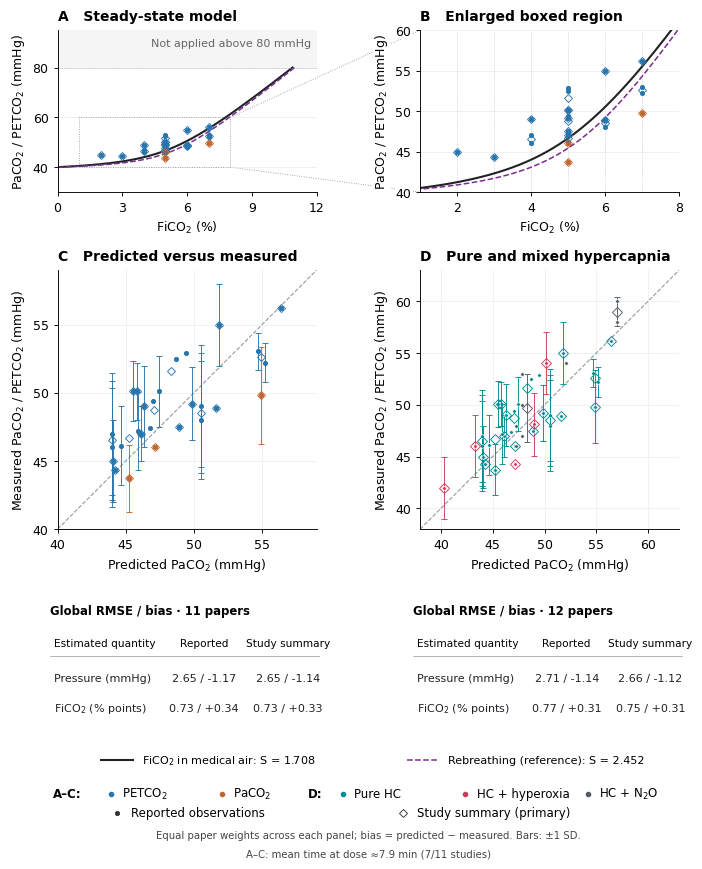

**Read the identity panels:** distance from the diagonal is model-minus-measurement disagreement. C uses pure HC; D reuses those observations and adds mixed conditions. The reference curve uses baseline 40 mmHg, while each identity prediction uses its paper’s matching baseline.

In [21]:
figure = combined(validation,print_size=True,payload=plot_payload)
display(figure)
plt.close(figure)

display(Markdown('**Read the identity panels:** distance from the diagonal is '
    'model-minus-measurement disagreement. C uses pure HC; D reuses those observations '
    'and adds mixed conditions. The reference curve uses baseline 40 mmHg, while '
    'each identity prediction uses its paper’s matching baseline.'))


<a id="duration-sd"></a>

### 12. Exposure duration and measured standard deviations

The duration summary uses **continuous exposure at the analysed inspired dose in A–C**, with one vote per paper and no participant weighting. Other dose stages, baseline and recovery are excluded. A paper contributes only when all its retained pure-HC comparisons have the same available duration; incomplete or differing durations are not replaced by a paper-level estimate. This available-case mean does not describe every included paper, and duration does not establish physiological steady state. Complete protocol descriptions and CO₂ measurement windows are recorded separately in the source data.

Identity-panel vertical bars show ±1 between-participant SD only where supported. SEM is converted using the matching N where justified; undefined ± terms are not assumed to be SD. Individual observations have no inferred within-participant SD. A pooled study SD requires compatible independent groups; repeated-acquisition covariance is not imputed. Missing SD is not zero.

These bars are neither confidence/prediction intervals nor residual SD. No horizontal SD is assigned to a deterministic conversion of group mean inputs.


In [22]:
duration = validation['duration_summary']
print(duration['figure_note'])
print('Time-at-dose range (min):',duration['range_minutes'])
print('Papers without a complete comparable duration:',', '.join(duration['missing_studies']))
show_table(validation['durations'],[('study_id','Paper'),('duration_minutes','Time at analysed dose (min)'),
    ('duration_status','Duration status')], detail='Expand duration for every eligible paper')
show_table([dict(series=key,**value) for key,value in plot_payload['uncertainty']['counts'].items()],
    [('series','Figure series'),('with_sd','Points with measured SD'),('total','Total points')])


A–C: mean time at dose ≈7.9 min (7/11 studies)
Time-at-dose range (min): [3.0, 25.0]
Papers without a complete comparable duration: Xu2011, Chawla2015, Ashkanian2008, Rostrup2000


Paper,Time at analysed dose (min),Duration status
Xu2011,Not available,partial
Deckers2022,4,approximate
Rodgers2015,5,exact
Jain2011,3,exact
Chawla2015,Not available,unknown
Ashkanian2008,Not available,unknown
Xie2006,5,exact
Reynolds1972,25,exact
Miller2019,9,approximate
Rostrup2000,Not available,partial


Figure series,Points with measured SD,Total points
reported,18,27
subject_weighted,11,20
comparison_reported,22,40
comparison_subject_weighted,17,27


<a id="supplement-scenarios"></a>

### 13. Optional supplementary sensitivity scenarios

Reproduce the supplementary comparison with CO₂ production at 160 or 250 mL/min STPD, and replacement of Peebles' PETCO₂ slope (1.6) by its arterial slope (1.7 L min⁻¹ mmHg⁻¹) from the **same 12 participants**. The replacement does not add participants. [Peebles et al. (2007)](https://doi.org/10.1113/jphysiol.2007.137075) report both slopes.

Production values are illustrative assumptions, not a literature range. Baseline ventilation is recalculated for each production scenario. These checks do not replace the operating model or identify the cause of error; lower RMSE is not a reason to tune parameters to these outcomes.


In [23]:
scenario_input=json.loads((DATA_ROOT/'data/supplement_sensitivity_inputs.json').read_text())
alternative=scenario_input['alternative_slope']
contributions=slope_evidence['fico2']['study_contributions']
replacement_slope=math.fsum(x['n_subjects']*(alternative['value'] if x['study_id']==alternative['study_id'] else x['slope'])
                           for x in contributions)/math.fsum(x['n_subjects'] for x in contributions)
scenarios=[('Operating',settings['VCO2'],settings['S'])]
scenarios += [(f'CO₂ production {v:g}',v,settings['S']) for v in scenario_input['production_scenarios_ml_min_stpd']]
scenarios += [('Peebles arterial slope substitution',settings['VCO2'],replacement_slope)]
scenario_rows=[]
for label,production,slope in scenarios:
    residuals=defaultdict(list)
    for row in primary_weighted:
        trial=parameters(dict(settings,VCO2=production,S=slope),row['baseline_mmhg'])
        residuals[row['study_id']].append((fico2_to_paco2(row['fico2_pct'],trial)-row['measured_mmhg'],
                                          paco2_to_fico2(row['measured_mmhg'],trial)-row['fico2_pct']))
    result={'scenario':label,'VCO2':production,'S':slope}
    for index,prefix in [(0,'pressure'),(1,'inspired')]:
        result[prefix+'_bias']=math.fsum(math.fsum(e[index] for e in values)/len(values) for values in residuals.values())/len(residuals)
        result[prefix+'_rmse']=math.sqrt(math.fsum(math.fsum(e[index]**2 for e in values)/len(values) for values in residuals.values())/len(residuals))
    scenario_rows.append(result)
show_table(scenario_rows,[('scenario','Scenario'),('VCO2','CO₂ production (mL/min)'),('S','S (L/min/mmHg)'),
    ('pressure_rmse','Pressure RMSE (mmHg)'),('pressure_bias','Pressure bias (mmHg)'),
    ('inspired_rmse','FiCO₂ RMSE (pp)'),('inspired_bias','FiCO₂ bias (pp)')])
assert p.S==settings['S'], 'Sensitivity must not change the operating model.'


Scenario,CO₂ production (mL/min),S (L/min/mmHg),Pressure RMSE (mmHg),Pressure bias (mmHg),FiCO₂ RMSE (pp),FiCO₂ bias (pp)
Operating,200,1.708,2.65,-1.136,0.7286,0.3324
CO₂ production 160,160,1.708,3.039,-1.863,0.8423,0.5565
CO₂ production 250,250,1.708,2.42,-0.3365,0.6729,0.08477
Peebles arterial slope substitution,200,1.745,2.681,-1.207,0.7375,0.3545


<a id="numerical-checks"></a>

## Checks

Check the closed-form converter against a separate bisection solution of the mass-balance equation and an explicit inverse expression. Independently assemble paper-level residual summaries for all global and dose/context metrics. Also check round trips, the fixed-ventilation limit and numerical guards.

These checks establish computational consistency with the frozen inputs, not physiological steady state, endpoint equivalence or individual prediction accuracy. No validation parameter is fitted during these checks. Package inputs and expected results remain inspectable in `data/`.


In [24]:
def independent_forward(dose_pct, params):
    """Bracket the mass-balance root without calling the converter."""
    def residual(P):
        return P-dose_pct*params.Pdry/100-params.K*params.VCO2/(params.VA_base+params.S*(P-params.PaCO2_base))
    low, high = params.PaCO2_base, params.max_paco2
    assert residual(low)<=1e-9 and residual(high)>=-1e-9
    for _ in range(90):
        middle=(low+high)/2
        if residual(middle)>0: high=middle
        else: low=middle
    return (low+high)/2

all_exact=validation['reported_points']+validation['weighted_points']
for row in all_exact:
    params=parameters(settings,row['baseline_mmhg'])
    forward=independent_forward(row['fico2_pct'],params)
    reverse=100*(row['measured_mmhg']-params.K*params.VCO2/
             (params.VA_base+params.S*(row['measured_mmhg']-params.PaCO2_base)))/params.Pdry
    assert math.isclose(forward,row['estimated_paco2_mmhg'],abs_tol=1e-10)
    assert math.isclose(reverse,row['estimated_fico2_pct'],abs_tol=1e-10)
    assert math.isclose(paco2_to_fico2(forward,params),row['fico2_pct'],abs_tol=1e-10)
    assert math.isclose(row['S'],slope_evidence['fico2']['slope'],abs_tol=1e-12)

def paper_metrics(rows,field):
    errors=defaultdict(list)
    for row in rows: errors[row['study_id']].append(row[field])
    bias=math.fsum(math.fsum(x)/len(x) for x in errors.values())/len(errors)
    mse=math.fsum(math.fsum(e*e for e in x)/len(x) for x in errors.values())/len(errors)
    return math.sqrt(mse),bias

for record in validation['global_metrics']+validation['combined_metrics']+validation['metrics']:
    rows=[x for x in all_exact if x['input_mode']==record['input_mode']]
    if 'panel' in record:
        rows=[x for x in rows if record['panel']=='D' or x['context']=='pure_HC']
    else:
        rows=[x for x in rows if x['context']==record['context'] and x['fico2_pct']==record['fico2_pct']
              and ('endpoint' not in record or x['endpoint']==record['endpoint'])]
    field='pressure_error_mmhg' if record['direction']=='FiCO2_to_pressure' else 'fico2_error_pct_points'
    rmse,bias=paper_metrics(rows,field)
    assert math.isclose(rmse,record['rmse'],abs_tol=1e-10)
    assert math.isclose(bias,record['bias'],abs_tol=1e-10)

fixed=replace(p,S=0)
assert math.isclose(fico2_to_paco2(2,fixed),fixed.PaCO2_base+0.02*fixed.Pdry,abs_tol=1e-10)
for pressure in [p.PaCO2_base-1,p.max_paco2+1]:
    try: paco2_to_fico2(pressure,p)
    except ValueError: pass
    else: raise AssertionError('Expected unsupported pressure to be rejected')
print(f'Passed: {len(all_exact)} bidirectional prediction pairs, global and stratified metrics, round trips and numerical guards.')


Passed: 67 bidirectional prediction pairs, global and stratified metrics, round trips and numerical guards.


<a id="next-steps"></a>

## Next Steps

Use appropriate known inputs, establish physiological steady state independently, and report outputs as conditional model estimates. Keep measurement compartment, reported gas mixture, baseline, parameter assumptions and uncertainty attached to every value.

The selected slope is an approximation from minute-ventilation/PETCO₂ measurements under finite-duration protocols. The rebreathing pooled mean is a heterogeneous descriptive reference. Neither is a universal physiological constant. An arterial–end-tidal gradient may contribute to residuals, but this aggregate evidence cannot isolate its contribution; a lower achieved PETCO₂ alone would not explain a negative predicted-minus-measured bias.

This package reproduces a fixed literature-input export. Changing its inputs is a new analysis and may intentionally fail the stored regression expectations. Do not update expected values simply to conceal a failed check. Keep a versioned code/data/notebook release together when reporting results.

A separate dynamic study and tutorial will address onset, transitions, recovery and breath-by-breath estimation, using the published steady-state model as a fixed comparator. Accuracy and precision require evaluation against measured time courses. PETCO₂ cannot directly validate PaCO₂ without arterial measurements or an explicit validated measurement model. No historical-priority claim is made here.
